# Código de prueba del Administrador de archivos.
Utiliza los archivos Administrar_Carpetas.py, Generar_Senales.py, Graficar.py.
1) Inicializa el administrador de archivos. Que genera la carpeta del proyecto ("Nro_Item"), con 3 carpetas adentro ("01 Respaldo", "02 Analisis de datos", "03 Resultados").
2) Según el valor de la bandera (True/False):
    1) Genera una señal de prueba, y una versión escalada por 25 para simular lo que entrega el osciloscopio.
    2) Toma los datos del osciloscopio.
3) Genera el arreglo del eje de tiempo.
4) Guarda la señal "original" en formato .BIN, en la carpeta "01 Respaldo".
5) Guarda la señal "procesada" en formato .H5, en la carpeta "02 Analisis de datos".
6) Guarda la señal "exportada" en formato .CSV, en la carpeta "03 Resultados".
7) Lee el archivo .BIN sin cabecera (del GW Instek 1000A-U), y grafica la señal.
8) Lee el archivo .BIN con cabecera (del GW Instek 1000A-U), y grafica la señal.
9) Lee el archivo .H5, y grafica la señal.
10) Lee el archivo .CSV, y grafica la señal.

Verificado: c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\01 Respaldo
Verificado: c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\02 Analisis de datos
Verificado: c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\03 Resultados
Se creó 'c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\01 Respaldo\Onda_20251211_195221.bin'
Se guardó datos originales en: c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\01 Respaldo\Onda_20251211_195221.bin
Se creó 'c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\02 Analisis de datos\Onda_20251211_195221_procesado.h5'
Se guardó datos procesados en: c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\02 Analisis de datos\Onda_20251211_195221_procesado.h5
Se creó 'c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\03 Resultados\Onda_20251211_195221_exportado.csv'
Se guardó datos exportados en: c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\03 Resultados\Onda_20251211_195221_exportado.csv

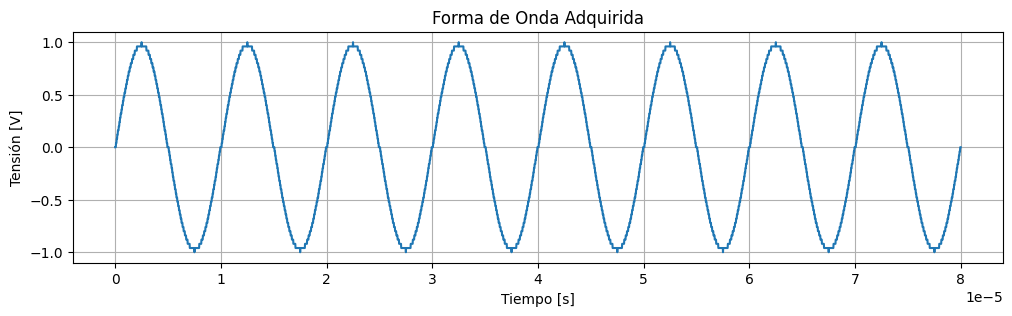

Se leyó datos originales desde: c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\02 Analisis de datos\Onda_20251211_195221_procesado.h5


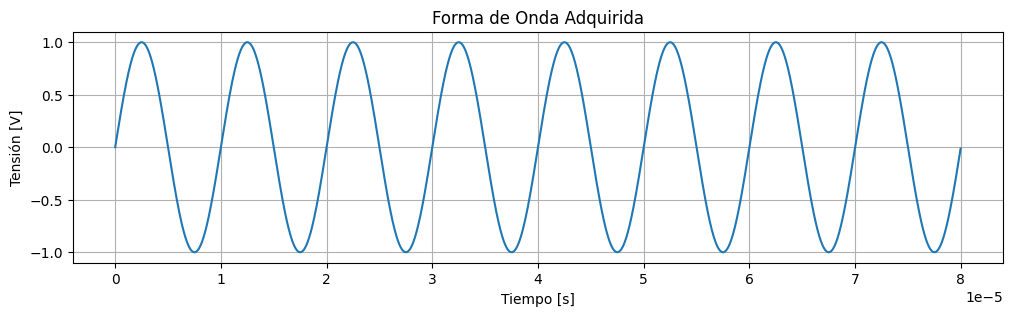

Se leyó datos originales desde: c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\03 Resultados\Onda_20251211_195221_exportado.csv


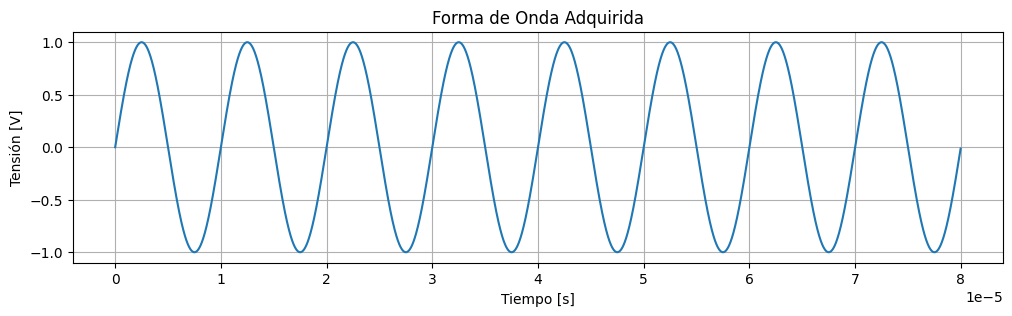

In [3]:
from Administrar_Carpetas import *
from Generar_Senales import *
from GWInstek_GDS1000A_U import *
from Report import *

if __name__ == '__main__':
    # 1. Al iniciar tu software, iniciar el gestor
    gestor = FileManager()

    bandera = True  # True: datos de prueba, False: datos desde osciloscopio

    if bandera:  # Generar datos de prueba
        dt = 20e-9
        binary_data, wave_form = generar_senales(dt)
    else:  # Obtener datos desde osciloscopio
        resource_manager = init_system()
        dso = init_instrument(resource_manager, 'ASRL6::INSTR')
        instrument = [resource_manager, dso]
        binary_data, wave_form, dt = get_block_data(instrument, 1)
    
    num_points = 4000
    time_axis = np.linspace(0, (num_points - 1) * dt, num_points)

    # 2. Guardar datos en .BIN:
    ruta_bin = gestor.get_new_name("Onda", ".bin")
    gestor.create_bin_int16(binary_data, ruta_bin)
    print(f"Se guardó datos originales en: {ruta_bin}")
    
    # 3. Guardar datos en .H5:
    nombre_base = ruta_bin.stem 
    ruta_h5 = gestor.analysis / f"{nombre_base}_procesado.h5"
    gestor.create_hdf5(time_axis, wave_form, ruta_h5)
    print(f"Se guardó datos procesados en: {ruta_h5}")

    # 4. Guardar datos en CSV:
    ruta_csv = gestor.results / f"{nombre_base}_exportado.csv"
    gestor.create_csv(time_axis, wave_form, ruta_csv)
    print(f"Se guardó datos exportados en: {ruta_csv}")

    # 5. Leer datos de .BIN, .H5 y .CSV y graficar:
    ruta_base = Path.cwd() / "DatosDePrueba"
    if bandera:
        wave1 = gestor.read_bin_without_header(ruta_bin)
        print(f"Se leyó datos originales desde: {ruta_bin}")
        #plot_waveform(wave1, dt)
        plot_waveform_2(wave1, time_axis)
    else:
        wave2, dt = gestor.read_bin_with_header(ruta_bin)
        print(f"Se leyó datos originales desde: {ruta_bin}")
        #plot_waveform(wave2, dt)
        plot_waveform_2(wave2, time_axis)

    wave3 = gestor.read_h5(ruta_h5)
    print(f"Se leyó datos originales desde: {ruta_h5}")
    #plot_waveform(wave3, dt)
    plot_waveform_2(wave3, time_axis)

    wave4 = gestor.read_csv(ruta_csv)
    print(f"Se leyó datos originales desde: {ruta_csv}")
    #plot_waveform(wave4, dt)
    plot_waveform_2(wave4, time_axis)

    if not bandera:
        close_system(instrument)
    '''
    # Evitar sobrescribir archivos existentes:
    Analizar el uso del siguiente código:
    
        if not os.path.exists("senales.csv"):
        # Guardar datos
        print("Se creó 'senales.csv'")
    else:
        print("El archivo ya existe, no se sobrescribió.")
    '''

# Código de prueba del Procesador de señales.
Utiliza los archivos Administrar_Carpetas.py, DSP.py, Report.py.
1) Lee el archivo de datos de calibración, y extrae su información.
2) Imprime los metadatos de la señal y su gráfico.
3) Calcula y quita el offset de la señal. Imprime su gráfico.
4) Calcula el pico de la señal, determina su polaridad, y normaliza la señal para que el máximo sea unitario. Imprime su gráfico.
5) Calcula y encuentra Ue * 0.2 del frente y Ue * 0.4 de la cola. Imprime su gráfico.

Verificado: c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\01 Respaldo
Verificado: c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\02 Analisis de datos
Verificado: c:\Users\Demian\Documents\RepositorioGit\PI\src\Nro_Item\03 Resultados
Versión de TDG: IEC 61083-2 TDG Version 2.1.0
Versión de archivo de datos: Data File Version  2.1.0
Nombre de onda: 01 LI-A1
Resolución de datos: 16 bits
Cantidad de muestras: 10000
Intervalo de muestreo: 10ns
Tasa de muestreo: 1e-08
Datos de la onda:

Total de puntos extraídos: 10000


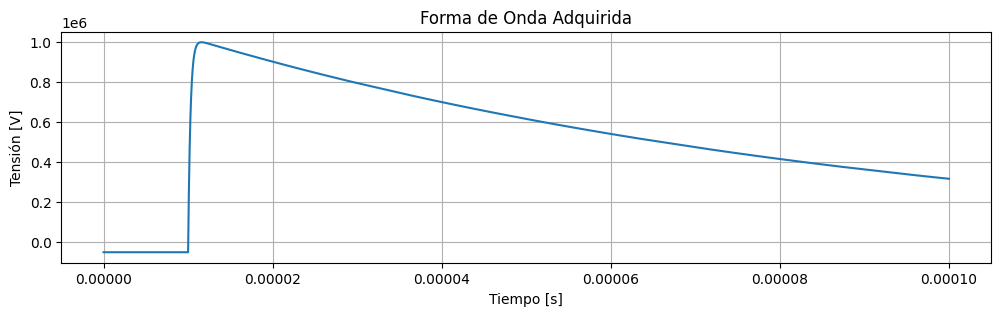

Offset removido: -50.00 kV


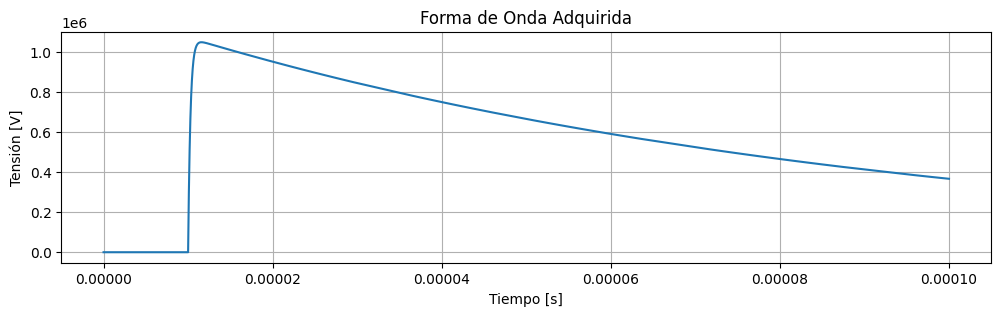

Pico detectado: 1049.59 kV
Polaridad: Positiva


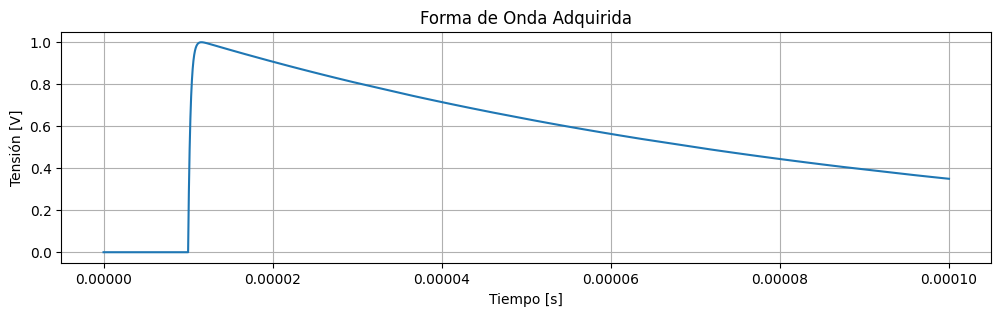

Pico = 1049.59 kV
umbral 20% = 209.92 kV, ID = 1007, V = 240.63 kV
umbral 40% = 419.83 kV, ID = 8873, V = 419.77 kV
Muestras seleccionadas para ajuste = 7866.


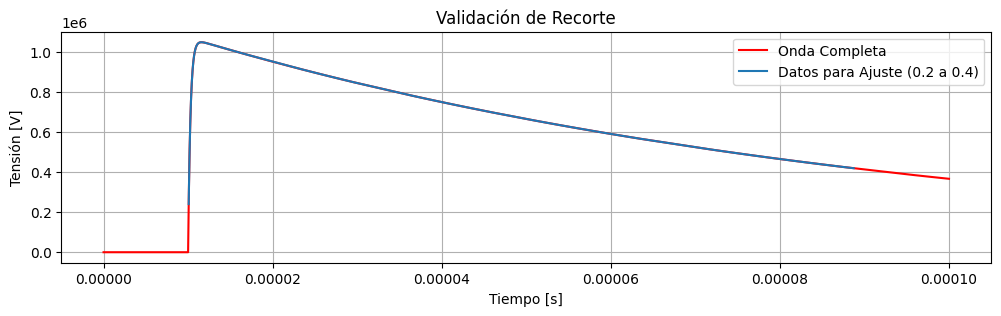

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
from Administrar_Carpetas import *
from DSP import *
from Report import *

if __name__ == "__main__":
    gestor = FileManager()
    calibration_file = Path.cwd() / "ArchivosCalibracion" / "LI-A1.txt"
    
    try:
        metadata, signal = gestor.read_calibration_file(calibration_file)
        print_information(metadata, signal)
        plot_waveform(signal, metadata['rate'])
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{calibration_file}'")
    except Exception as e:
        print(f"Error al procesar el archivo: {e}")
    
    # Paso 1: Quitar Offset
    analyzer = LightningImpulseAnalyzer(signal, metadata['rate'])
    offset = analyzer.remove_offset()
    print(f"Offset removido: {offset/1000:.2f} kV")
    plot_waveform(analyzer.zeroed_voltage, metadata['rate'])

    # Paso 2: Normalizar y detectar pico
    peak, polarity = analyzer.normalize_waveform()
    print(f"Pico detectado: {peak/1000:.2f} kV")
    print(f"Polaridad: {polarity}")
    # Graficar la señal normalizada
    plot_waveform(analyzer.norm_voltage, metadata['rate'])

    # Paso 3: Recortar la señal entre 20 % del frente y 40 % de la cola.
    try:
        t_cut, v_cut, v_cut_norm = analyzer.cutting_signal()
        print(f"Muestras seleccionadas para ajuste = {len(v_cut)}.")
        plot_cutting_signal(analyzer.time_axis, analyzer.zeroed_voltage, t_cut, v_cut)
    except ValueError as e:
        print(e)
    
    """
    # Paso 4: Ajuste de la señal recortada con función de doble exponencial.
    try:
        popt, pcov = analyzer.fit_double_exponential()
        print("Parámetros ajustados de la doble exponencial:")
        print(f"A = {popt[0]:.4f}, tau1 = {popt[1]:.6f} s, tau2 = {popt[2]:.6f} s, td = {popt[3]:.6f} s")
        
        # Graficar el ajuste
        v_fit_adjusted = analyzer.double_exponential(t_fit, *popt)
        
        plt.figure(figsize=(12, 3))
        plt.plot(t_fit, v_fit, 'b.', label='Datos para Ajuste')
        plt.plot(t_fit, v_fit_adjusted, 'r-', label='Ajuste Doble Exponencial')
        plt.title("Ajuste de Doble Exponencial")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Tensión [V]")
        plt.legend()
        plt.grid(True)
        plt.show()
    """